# 06 - Debug Artifact Alignment

Notebook này kiểm tra alignment giữa `clip_image_embeddings_full.npy`, `clip_faiss_index_full.index`, và `clip_full_metadata.json` trước khi sửa Streamlit app.

## 1. Import libraries and define paths

In [1]:
import json
from pathlib import Path

import faiss
import matplotlib.pyplot as plt
import numpy as np
import PIL.Image
import torch
from transformers import CLIPModel, CLIPProcessor


PROJECT_ROOT = Path("..").resolve()

IMAGE_EMBEDDINGS_PATH = PROJECT_ROOT / "data/processed/clip_image_embeddings_full.npy"
FAISS_INDEX_PATH = PROJECT_ROOT / "data/processed/clip_faiss_index_full.index"
METADATA_PATH = PROJECT_ROOT / "data/processed/clip_full_metadata.json"

MODEL_NAME = "openai/clip-vit-base-patch32"
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

print(f"Device: {DEVICE}")

d:\CITD\HK3\Python for ML\Clip_Retrieval\clip-faiss-search\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Device: cuda


## 2. Load artifacts

In [2]:
image_embeddings = np.load(IMAGE_EMBEDDINGS_PATH)
index = faiss.read_index(str(FAISS_INDEX_PATH))

with METADATA_PATH.open("r", encoding="utf-8") as file:
    metadata = json.load(file)

print(f"IMAGE_EMBEDDINGS_PATH: {IMAGE_EMBEDDINGS_PATH}")
print(f"FAISS_INDEX_PATH: {FAISS_INDEX_PATH}")
print(f"METADATA_PATH: {METADATA_PATH}")
print(f"image_embeddings.shape: {image_embeddings.shape}")
print(f"image_embeddings.dtype: {image_embeddings.dtype}")
print(f"index.ntotal: {index.ntotal}")
print(f"len(metadata): {len(metadata)}")
print("metadata[0]:")
print(metadata[0])

assert image_embeddings.shape[0] == len(metadata), "image_embeddings and metadata length mismatch"
assert index.ntotal == len(metadata), "FAISS index and metadata length mismatch"

IMAGE_EMBEDDINGS_PATH: D:\CITD\HK3\Python for ML\Clip_Retrieval\clip-faiss-search\data\processed\clip_image_embeddings_full.npy
FAISS_INDEX_PATH: D:\CITD\HK3\Python for ML\Clip_Retrieval\clip-faiss-search\data\processed\clip_faiss_index_full.index
METADATA_PATH: D:\CITD\HK3\Python for ML\Clip_Retrieval\clip-faiss-search\data\processed\clip_full_metadata.json
image_embeddings.shape: (31782, 512)
image_embeddings.dtype: float32
index.ntotal: 31782
len(metadata): 31782
metadata[0]:
{'image_id': '1000092795.jpg', 'image_path': 'data/raw/Images/1000092795.jpg', 'captions': ['Two young guys with shaggy hair look at their hands while hanging out in the yard .', 'Two young , White males are outside near many bushes .', 'Two men in green shirts are standing in a yard .', 'A man in a blue shirt standing in a garden .', 'Two friends enjoy time spent together .']}


## 3. Check FAISS index vs image_embeddings

Nếu cell này fail, nghĩa là FAISS index không khớp file `clip_image_embeddings_full.npy`.

In [3]:
reconstructed = index.reconstruct(0)
diff = np.max(np.abs(reconstructed - image_embeddings[0]))

print(f"Max diff index[0] vs image_embeddings[0]: {diff:.10f}")

assert diff < 1e-5, "FAISS index does not match clip_image_embeddings_full.npy"

Max diff index[0] vs image_embeddings[0]: 0.0000000000


## 4. Load CLIP model

In [4]:
model = CLIPModel.from_pretrained(MODEL_NAME)
processor = CLIPProcessor.from_pretrained(MODEL_NAME)
model.to(DEVICE)
model.eval()

print(f"Model loaded on device: {DEVICE}")

Loading weights: 100%|██████████| 398/398 [00:00<00:00, 30081.32it/s]
CLIPModel LOAD REPORT from: openai/clip-vit-base-patch32
Key                                  | Status     |  | 
-------------------------------------+------------+--+-
vision_model.embeddings.position_ids | UNEXPECTED |  | 
text_model.embeddings.position_ids   | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Model loaded on device: cuda


## 5. Define encode functions

In [5]:
def _to_clip_tensor(features):
    if torch.is_tensor(features):
        return features
    if hasattr(features, "text_embeds"):
        return features.text_embeds
    if hasattr(features, "image_embeds"):
        return features.image_embeds
    if hasattr(features, "pooler_output"):
        return features.pooler_output
    raise TypeError(f"Unsupported CLIP output type: {type(features).__name__}")


def encode_text_query(query):
    inputs = processor(
        text=[query],
        return_tensors="pt",
        padding=True,
        truncation=True,
    )
    inputs = {key: value.to(DEVICE) for key, value in inputs.items()}

    with torch.no_grad():
        text_features = model.get_text_features(**inputs)
        text_features = _to_clip_tensor(text_features)
        if text_features.shape[-1] != model.config.projection_dim and hasattr(model, "text_projection"):
            text_features = model.text_projection(text_features)
        text_features = text_features / text_features.norm(dim=-1, keepdim=True)

    text_features = text_features.cpu().numpy().astype(np.float32)
    assert text_features.shape == (1, 512), f"Unexpected text embedding shape: {text_features.shape}"
    return text_features


def encode_image_from_path(image_path):
    image = PIL.Image.open(image_path).convert("RGB")
    inputs = processor(images=[image], return_tensors="pt")
    inputs = {key: value.to(DEVICE) for key, value in inputs.items()}

    with torch.no_grad():
        image_features = model.get_image_features(**inputs)
        image_features = _to_clip_tensor(image_features)
        if image_features.shape[-1] != model.config.projection_dim and hasattr(model, "visual_projection"):
            image_features = model.visual_projection(image_features)
        image_features = image_features / image_features.norm(dim=-1, keepdim=True)

    image_features = image_features.squeeze(0).cpu().numpy().astype(np.float32)
    assert image_features.shape == (512,), f"Unexpected image embedding shape: {image_features.shape}"
    return image_features

## 6. Critical alignment test

Kiểm tra embedding lưu ở `image_embeddings[i]` có thật sự thuộc về ảnh `metadata[i]` không. Nếu alignment đúng, cosine nên rất gần `1.0`, ví dụ `> 0.99`.

In [6]:
test_indices = [0, 1, 2, 10, 100, 500, 1000, 5000, 10000, 20000, len(metadata) - 1]
alignment_cosines = []

for idx in test_indices:
    item = metadata[idx]
    image_path = PROJECT_ROOT / item["image_path"]
    online_emb = encode_image_from_path(image_path)
    saved_emb = image_embeddings[idx].astype(np.float32)
    cosine = float(online_emb @ saved_emb)
    alignment_cosines.append(cosine)
    print(f"idx={idx:6d} | image_id={item['image_id']} | cosine={cosine:.6f}")

min_alignment_cosine = min(alignment_cosines)
alignment_ok = min_alignment_cosine > 0.99

print(f"\nMin alignment cosine: {min_alignment_cosine:.6f}")
print(f"Alignment OK (> 0.99): {alignment_ok}")

idx=     0 | image_id=1000092795.jpg | cosine=1.000000
idx=     1 | image_id=10002456.jpg | cosine=0.999999
idx=     2 | image_id=1000268201.jpg | cosine=1.000000
idx=    10 | image_id=1001573224.jpg | cosine=1.000000
idx=   100 | image_id=1029737941.jpg | cosine=0.999993
idx=   500 | image_id=1159425410.jpg | cosine=1.000000
idx=  1000 | image_id=1314231418.jpg | cosine=0.999999
idx=  5000 | image_id=2330310763.jpg | cosine=0.999998
idx= 10000 | image_id=2952751562.jpg | cosine=0.999999
idx= 20000 | image_id=4461519605.jpg | cosine=1.000000
idx= 31781 | image_id=998845445.jpg | cosine=0.999998

Min alignment cosine: 0.999993
Alignment OK (> 0.99): True


## 7. Query sanity check with FAISS and brute-force

Kỳ vọng FAISS và brute-force giống nhau hoặc gần như giống nhau. Nếu cùng sai thì lỗi nằm ở `image_embeddings`/`metadata`/model alignment. Nếu khác nhau thì lỗi nằm ở FAISS index.

In [7]:
query = "a dog running on the grass"
query_emb = encode_text_query(query)

faiss_scores, faiss_indices = index.search(query_emb, 10)

scores = image_embeddings @ query_emb.squeeze(0)
brute_indices = np.argsort(scores)[::-1][:10]

print(f"Query: {query}\n")
print("FAISS top-10")
for rank, (idx, score) in enumerate(zip(faiss_indices[0], faiss_scores[0]), start=1):
    item = metadata[int(idx)]
    print(f"{rank:2d}. idx={int(idx):6d} | image_id={item['image_id']} | score={float(score):.6f} | caption={item['captions'][0]}")

print("\nBrute-force top-10")
for rank, idx in enumerate(brute_indices, start=1):
    item = metadata[int(idx)]
    print(f"{rank:2d}. idx={int(idx):6d} | image_id={item['image_id']} | score={float(scores[idx]):.6f} | caption={item['captions'][0]}")

faiss_top10 = [int(idx) for idx in faiss_indices[0]]
brute_top10 = [int(idx) for idx in brute_indices]
faiss_matches_bruteforce = faiss_top10 == brute_top10
faiss_overlap_bruteforce = len(set(faiss_top10) & set(brute_top10))

print(f"\nExact top-10 match: {faiss_matches_bruteforce}")
print(f"Top-10 overlap: {faiss_overlap_bruteforce}/10")

Query: a dog running on the grass

FAISS top-10
 1. idx= 10217 | image_id=2982928615.jpg | score=0.346229 | caption=The dog is running quickly through the meadow .
 2. idx= 15625 | image_id=3597924257.jpg | score=0.343511 | caption=A brown dog runs through a field of grass spotted with yellow flowers
 3. idx= 15097 | image_id=3540416139.jpg | score=0.339046 | caption=A golden dog is running across the grass chasing a white toy on the ground .
 4. idx= 20924 | image_id=456512643.jpg | score=0.338647 | caption=A tan dog is running fast through tall green grass .
 5. idx=  3866 | image_id=2180480870.jpg | score=0.335288 | caption=Tan dog running through long grass in a park-like setting .
 6. idx=  1849 | image_id=1514957266.jpg | score=0.333437 | caption=A black dog runs on green grass with its mouth open .
 7. idx=  8239 | image_id=2730994020.jpg | score=0.331944 | caption=A black and white shorthair dog runs across brown and green grass .
 8. idx=  7344 | image_id=2613993276.jpg | scor

## 8. Dog caption hit test

Nếu `Hit@10` là `False`, artifact hoặc embedding pipeline chắc chắn có vấn đề.

In [8]:
gt_idx = None
gt_caption = None

for i, item in enumerate(metadata):
    for cap in item["captions"]:
        if "dog" in cap.lower():
            gt_idx = i
            gt_caption = cap
            break
    if gt_idx is not None:
        break

assert gt_idx is not None, "No caption containing 'dog' was found in metadata"

gt_query_emb = encode_text_query(gt_caption)
gt_scores, gt_indices = index.search(gt_query_emb, 10)
retrieved_image_ids = [metadata[int(idx)]["image_id"] for idx in gt_indices[0]]
hit_at_10 = gt_idx in [int(idx) for idx in gt_indices[0]]

print(f"gt_idx: {gt_idx}")
print(f"ground truth image_id: {metadata[gt_idx]['image_id']}")
print(f"gt_caption: {gt_caption}")
print("retrieved top-10 image_ids:")
for rank, image_id in enumerate(retrieved_image_ids, start=1):
    print(f"{rank:2d}. {image_id}")
print(f"Hit@10: {hit_at_10}")

gt_idx: 12
ground truth image_id: 1001773457.jpg
gt_caption: A black dog and a white dog with brown spots are staring at each other in the street .
retrieved top-10 image_ids:
 1. 1368338041.jpg
 2. 1001773457.jpg
 3. 3357937209.jpg
 4. 4874913189.jpg
 5. 2276499757.jpg
 6. 909808296.jpg
 7. 386656845.jpg
 8. 4717627685.jpg
 9. 3033612929.jpg
10. 2608116127.jpg
Hit@10: True


## 9. Visualize alignment example

Hiển thị top-5 ảnh từ metadata theo FAISS index cho query `a dog running on the grass`, tương tự Streamlit.

idx= 10217 | image_id=2982928615.jpg | score=0.346229 | caption=The dog is running quickly through the meadow .
idx= 15625 | image_id=3597924257.jpg | score=0.343511 | caption=A brown dog runs through a field of grass spotted with yellow flowers
idx= 15097 | image_id=3540416139.jpg | score=0.339046 | caption=A golden dog is running across the grass chasing a white toy on the ground .
idx= 20924 | image_id=456512643.jpg | score=0.338647 | caption=A tan dog is running fast through tall green grass .
idx=  3866 | image_id=2180480870.jpg | score=0.335288 | caption=Tan dog running through long grass in a park-like setting .


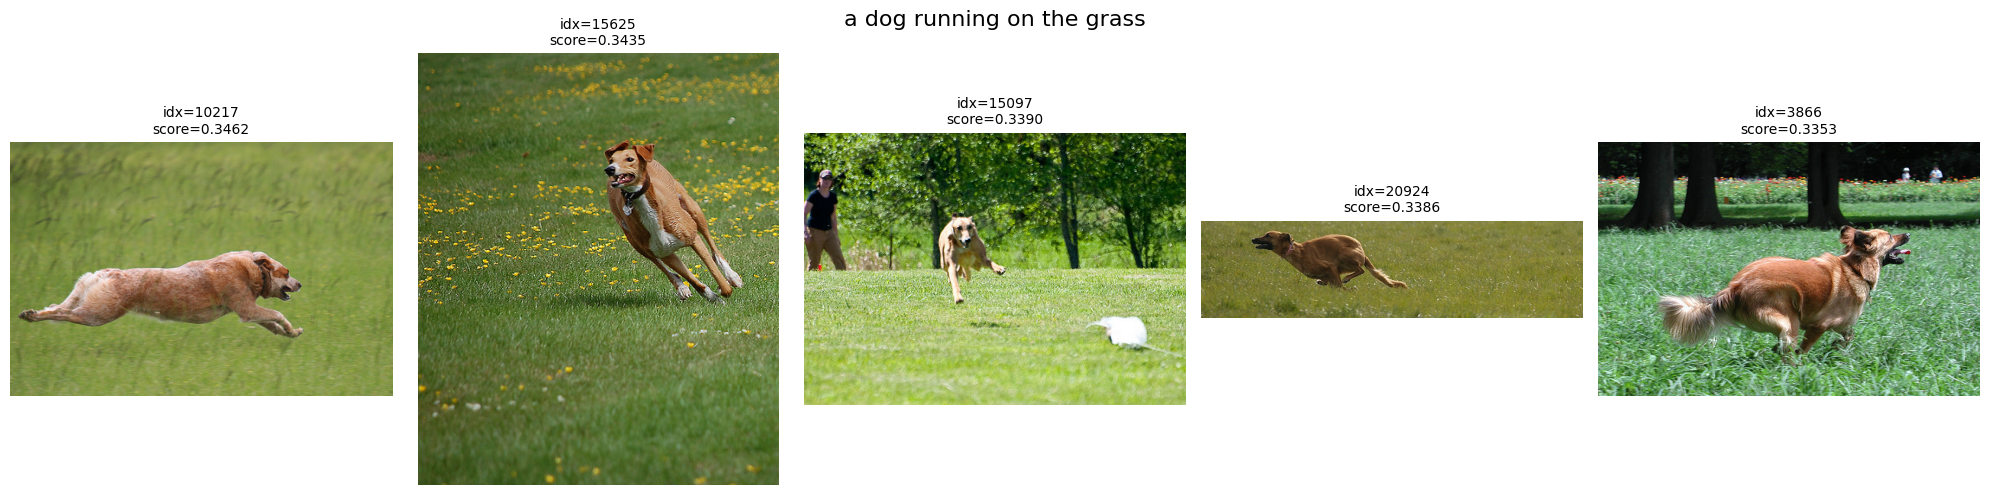

In [9]:
query = "a dog running on the grass"
query_emb = encode_text_query(query)
vis_scores, vis_indices = index.search(query_emb, 5)

fig, axes = plt.subplots(1, 5, figsize=(20, 5))
fig.suptitle(query, fontsize=16)

for ax, idx, score in zip(axes, vis_indices[0], vis_scores[0]):
    item = metadata[int(idx)]
    image_path = PROJECT_ROOT / item["image_path"]
    image = PIL.Image.open(image_path).convert("RGB")
    ax.imshow(image)
    ax.axis("off")
    ax.set_title(f"idx={int(idx)}\nscore={float(score):.4f}", fontsize=10)
    print(f"idx={int(idx):6d} | image_id={item['image_id']} | score={float(score):.6f} | caption={item['captions'][0]}")

plt.tight_layout()
plt.show()

## 10. Conclusion cell

In [10]:
print("Conclusion")
print("----------")

if alignment_ok and hit_at_10 and faiss_matches_bruteforce:
    print("Artifact alignment ổn, cần kiểm tra app runtime.")
elif not alignment_ok:
    print("Alignment cosine thấp.")
    print("Cần rebuild clip_image_embeddings_full.npy và clip_faiss_index_full.index từ cùng một metadata order.")
elif not faiss_matches_bruteforce:
    print("FAISS khác brute-force.")
    print("Cần rebuild FAISS index từ image_embeddings hiện tại.")
elif not hit_at_10:
    print("Dog caption Hit@10 False.")
    print("Artifact hoặc embedding pipeline chắc chắn có vấn đề.")
else:
    print("Không rơi vào case rõ ràng. Kiểm tra chi tiết các output phía trên.")

print(f"Min alignment cosine: {min_alignment_cosine:.6f}")
print(f"Hit@10: {hit_at_10}")
print(f"FAISS exact top-10 match brute-force: {faiss_matches_bruteforce}")
print(f"FAISS/brute-force top-10 overlap: {faiss_overlap_bruteforce}/10")

Conclusion
----------
Artifact alignment ổn, cần kiểm tra app runtime.
Min alignment cosine: 0.999993
Hit@10: True
FAISS exact top-10 match brute-force: True
FAISS/brute-force top-10 overlap: 10/10
